# BUSINESS OBJECTIVE



The goal of this project is to analyze retail sales data to:

1. Identify key revenue and profit drivers across products, categories, and regions
2. Detect loss-making products and inefficient business segments
3. Understand sales trends and seasonal patterns
4. Evaluate the impact of pricing and discount strategies on profitability
5. Provide data-driven recommendations to improve overall business performance


# Dataset Overview


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# settings
sns.set_style('darkgrid')

In [ ]:
import sqlite3

conn = sqlite3.connect('sales.db')

In [ ]:
import pandas as pd

# Load the Dataset
df = pd.read_csv('/content/superstore_dataset.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Basic info about the dataset
print(" Dataset Information:")
print("----------------------")
print(df.info())
print("==============================")
print(" Dataset Description:")
print("---------------------")
print(df.describe())

print("==============================")
print(" Dataset Shape:")
print("----------------")
print(df.shape)

print("==============================")
print(" Dataset Columns:")
print("------------------")
print(df.columns)

print("==============================")

 Dataset Information:
----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales  

# Data Preparation & Cleaning

In [ ]:
# Check for missing values
print("\n❗ Missing Values per Column:")
print(df.isnull().sum())


❗ Missing Values per Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
df.drop(columns=['Postal Code'], inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11


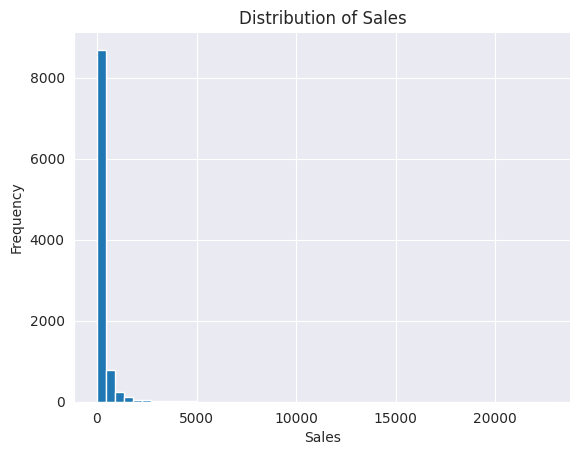

In [ ]:
# Distribution of Sales
plt.hist(df['Sales'], bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

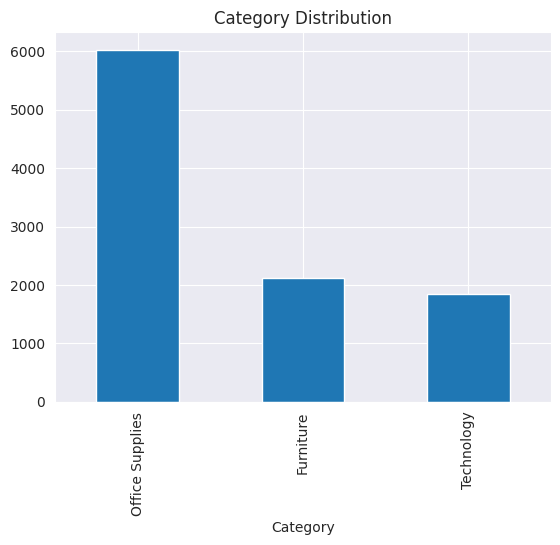

In [ ]:
# Categry Distribution
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

## Bivariate Analysis

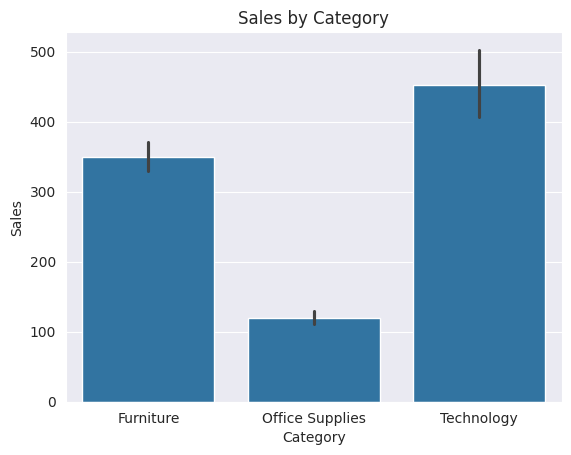

In [ ]:
# Sales by Category
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

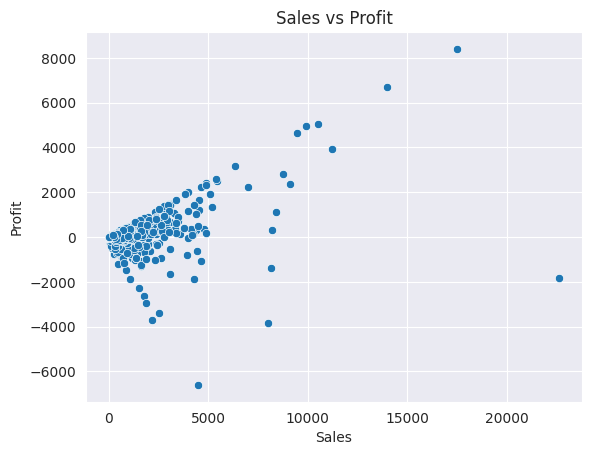

In [ ]:
# Sales vs Profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

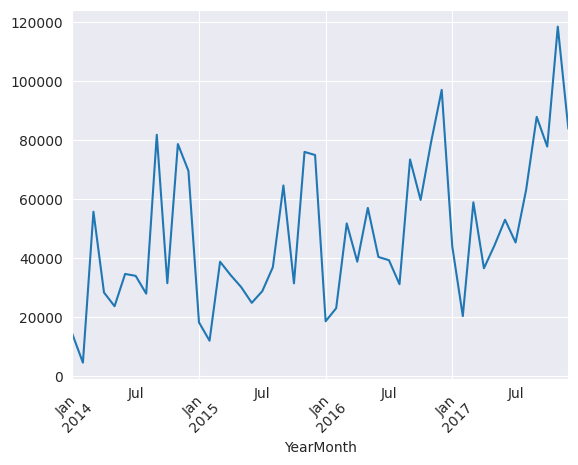

In [ ]:
# Time Series Analysis
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales.plot()
plt.xticks(rotation=45)
plt.show()

# Business-Level Analysis

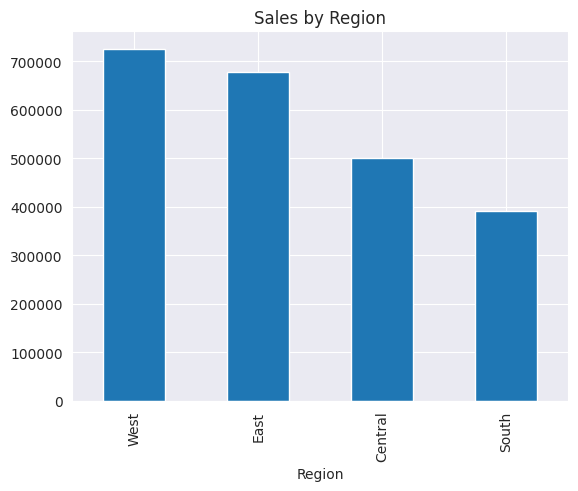

In [ ]:
# Region-wise sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

print("Worst Region (Profit):", region_profit.idxmin())
print("Best Region (Profit):", region_profit.idxmax())

Worst Region (Profit): Central
Best Region (Profit): West


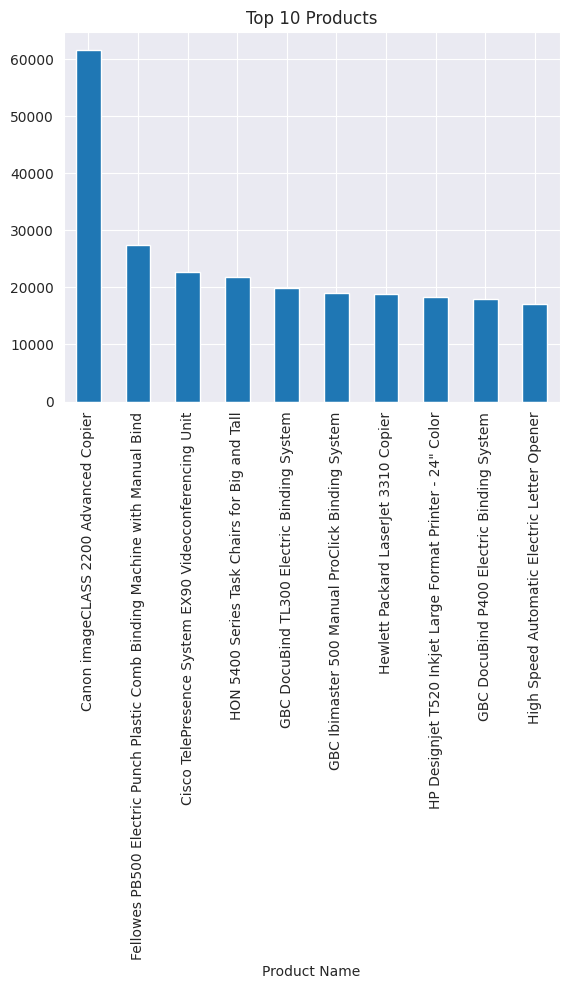

In [ ]:
# Top 10 products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

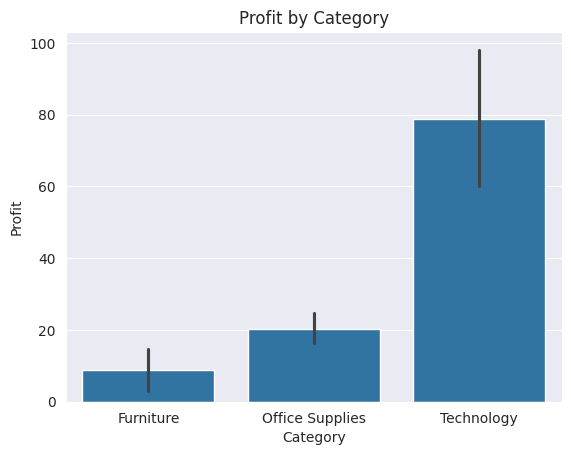

In [ ]:
# Profit by Category
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

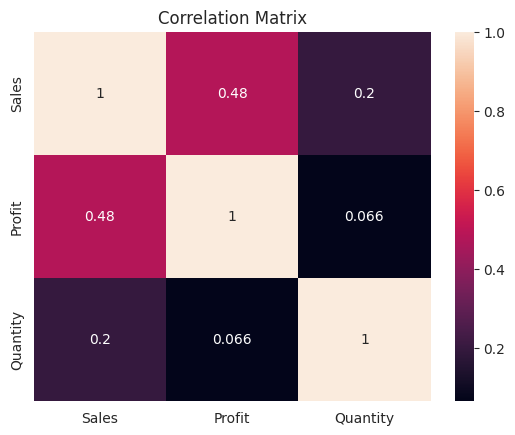

In [ ]:


# Correlation
sns.heatmap(df[['Sales','Profit','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# ==============================
# 🔥 PROFIT-FOCUSED ANALYSIS
# ==============================

# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
print("Profit by Region:\n", region_profit)

# Profit Margin
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
print(f"Profit Margin: {profit_margin:.2%}")
print("Insight: Overall profitability is moderate, indicating scope for margin improvement.")

# Profit Margin by Category
category = df.groupby('Category').agg({'Sales':'sum','Profit':'sum'})
category['Profit Margin'] = category['Profit'] / category['Sales']
print(category)

# Loss-making products
loss_products = df[df['Profit'] < 0]
loss_summary = loss_products.groupby('Product Name')['Profit'].sum().sort_values().head(10)
print("Top Loss Making Products:\n", loss_summary)

Profit by Region:
 Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64
Profit Margin: 12.47%
Insight: Overall profitability is moderate, indicating scope for margin improvement.
                       Sales       Profit  Profit Margin
Category                                                
Furniture        741999.7953   18451.2728       0.024867
Office Supplies  719047.0320  122490.8008       0.170352
Technology       836154.0330  145454.9481       0.173957
Top Loss Making Products:
 Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                       

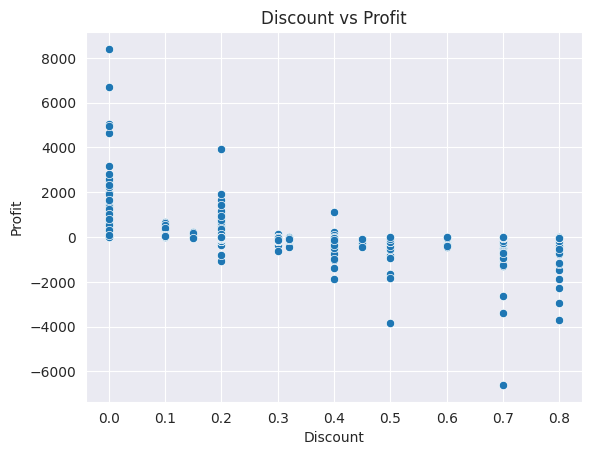

Insight: Higher discounts tend to reduce profit significantly.


In [ ]:
# Discount vs Profit
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()
print("Insight: Higher discounts tend to reduce profit significantly.")


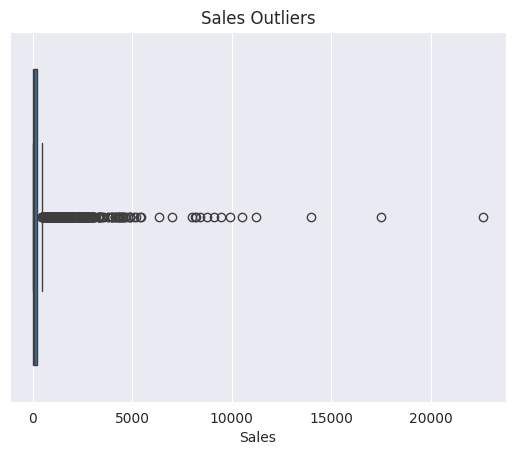

In [ ]:
# Outlier Detection
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

# Key Insights

In [ ]:

# ==============================
# 🔥 BUSINESS INSIGHTS
# ==============================

# 1. West region generates highest revenue but requires margin validation for efficiency
# 2. High discount levels show clear negative correlation with profit, indicating margin erosion
# 3. Several products generate high revenue but contribute negatively to overall profitability
# 4. Technology category delivers the highest profit margin, making it the most efficient segment

# KPI Summary

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df.shape[0]

profit_margin = total_profit / total_sales

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Profit Margin:", profit_margin)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 9994
Profit Margin: 0.12467217240315603


In [ ]:
# ==============================
# 💡 RECOMMENDATIONS
# ==============================

# 1. Reduce discounting on low-margin products
# 2. Focus on high-profit categories like Technology
# 3. Identify and remove or reprice loss-making products
# 4. Improve profitability in low-performing regions

In [ ]:
# Priority 1: Reduce discounting on loss-making products to stop profit leakage
# Priority 2: Focus on Technology category for higher returns
# Priority 3: Review pricing strategy for consistently negative-profit products
# Priority 4: Improve operational efficiency in low-profit regions

In [ ]:
print("\n===== FINAL BUSINESS SUMMARY =====")

print(f"Worst Region (Profit): {region_profit.idxmin()}")
print(f"Best Region (Profit): {region_profit.idxmax()}")
print(f"Overall Profit Margin: {profit_margin:.2%}")

print("\nKey Issue: Some products and regions are generating losses despite strong sales.")
print("Action: Focus on pricing and discount optimization.")


===== FINAL BUSINESS SUMMARY =====
Worst Region (Profit): Central
Best Region (Profit): West
Overall Profit Margin: 12.47%

Key Issue: Some products and regions are generating losses despite strong sales.
Action: Focus on pricing and discount optimization.


In [ ]:
# ==============================
# 🗄️ SQL ANALYSIS (VALIDATION)
# ==============================

import sqlite3
import pandas as pd

# connect database
conn = sqlite3.connect('sales.db')

# Convert 'YearMonth' column to string before loading to SQL
df['YearMonth'] = df['YearMonth'].astype(str)

# Load the DataFrame into a SQL table named 'orders'
df.to_sql('orders', conn, if_exists='replace', index=False)

# Query 1: Profit by Region
query1 = """
SELECT Region, SUM(Profit) as total_profit
FROM orders
GROUP BY Region
ORDER BY total_profit;
"""

print("\nSQL - Profit by Region:")
print(pd.read_sql(query1, conn))


# Query 2: Loss-making Products
query2 = """
SELECT "Product Name", SUM(Profit) as total_profit
FROM orders
GROUP BY "Product Name"
HAVING total_profit < 0
ORDER BY total_profit;
"""

print("\nSQL - Loss Making Products:")
print(pd.read_sql(query2, conn))

# Close the connection
conn.close()


SQL - Profit by Region:
    Region  total_profit
0  Central    39706.3625
1    South    46749.4303
2     East    91522.7800
3     West   108418.4489

SQL - Loss Making Products:
                                          Product Name  total_profit
0            Cubify CubeX 3D Printer Double Head Print -8.879970e+03
1            Lexmark MX611dhe Monochrome Laser Printer -4.589973e+03
2            Cubify CubeX 3D Printer Triple Head Print -3.839990e+03
3    Chromcraft Bull-Nose Wood Oval Conference Tabl... -2.876116e+03
4    Bush Advantage Collection Racetrack Conference... -1.934398e+03
..                                                 ...           ...
296                 Brites Rubber Bands, 1 1/2 oz. Box -5.148000e-01
297                                   Rubber Band Ball -2.992000e-01
298  Acco PRESSTEX Data Binder with Storage Hooks, ... -1.614000e-01
299                     Premier Electric Letter Opener -7.105427e-15
300                           Global Super Steno Chair -1.7763

In [111]:
with open('analysis.sql', 'r') as f:
    print(f.read())

FileNotFoundError: [Errno 2] No such file or directory: 'analysis.sql'

In [113]:
import os
print(os.getcwd())

/content


In [114]:
print(os.listdir())

['.config', 'sales.db', 'superstore_dataset.csv', 'sample_data']


In [115]:
with open('analysis.sql', 'w') as f:
    f.write("""
-- SQL Queries Here
SELECT Region, SUM(Profit)
FROM orders
GROUP BY Region;
""")

In [116]:
with open('analysis.sql', 'r') as f:
    print(f.read())


-- SQL Queries Here
SELECT Region, SUM(Profit)
FROM orders
GROUP BY Region;



In [117]:
with open('analysis.sql', 'w') as f:
    f.write("""
-- =====================================
-- RETAIL SALES ANALYSIS (SQL)
-- =====================================

-- 1. Total Sales & Profit
SELECT
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit
FROM orders;


-- 2. Profit by Region
SELECT
    Region,
    SUM(Profit) AS total_profit
FROM orders
GROUP BY Region
ORDER BY total_profit;


-- 3. Worst & Best Region (Profit)
SELECT
    Region,
    SUM(Profit) AS total_profit
FROM orders
GROUP BY Region
ORDER BY total_profit ASC;


-- 4. Top 10 Products by Sales
SELECT
    "Product Name",
    SUM(Sales) AS revenue
FROM orders
GROUP BY "Product Name"
ORDER BY revenue DESC
LIMIT 10;


-- 5. Loss-making Products
SELECT
    "Product Name",
    SUM(Profit) AS total_profit
FROM orders
GROUP BY "Product Name"
HAVING total_profit < 0
ORDER BY total_profit;
""")

In [118]:
with open('analysis.sql', 'r') as f:
    print(f.read())


-- =====================================
-- RETAIL SALES ANALYSIS (SQL)
-- =====================================

-- 1. Total Sales & Profit
SELECT 
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit
FROM orders;


-- 2. Profit by Region
SELECT 
    Region,
    SUM(Profit) AS total_profit
FROM orders
GROUP BY Region
ORDER BY total_profit;


-- 3. Worst & Best Region (Profit)
SELECT 
    Region,
    SUM(Profit) AS total_profit
FROM orders
GROUP BY Region
ORDER BY total_profit ASC;


-- 4. Top 10 Products by Sales
SELECT 
    "Product Name",
    SUM(Sales) AS revenue
FROM orders
GROUP BY "Product Name"
ORDER BY revenue DESC
LIMIT 10;


-- 5. Loss-making Products
SELECT 
    "Product Name",
    SUM(Profit) AS total_profit
FROM orders
GROUP BY "Product Name"
HAVING total_profit < 0
ORDER BY total_profit;

